# IN HIS NAME
## NNDL - HW4 - Q1
## Rajabzadeh, Ali - 810104137

In [225]:
!pip install seqeval

# Import libraries we need

In [226]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
from seqeval.metrics import f1_score, classification_report
from torch.nn.utils.rnn import pad_sequence

# Part 1.1 : Data Preparation

## Part 1.1.1

In [227]:
path = kagglehub.dataset_download("siddhadev/atis-dataset-clean")
print("Path to dataset files:", path)
print("Directory contents of Path:", os.listdir(path))

Path to dataset files: /kaggle/input/atis-dataset-clean
Directory contents of Path: ['atis.dev.csv', 'atis.train.csv', 'atis.test.csv']


In [228]:
train_path = os.path.join(path, "atis.train.csv")
dev_path = os.path.join(path, "atis.dev.csv")
test_path = os.path.join(path, "atis.test.csv")

train_df = pd.read_csv(train_path)
dev_df = pd.read_csv(dev_path)
test_df = pd.read_csv(test_path)

print(f"Number of training instances: {len(train_df)}")
print(f"Number of development instances: {len(dev_df)}")
print(f"Number of test instances: {len(test_df)}")

summary_df = pd.DataFrame({
    "Split": ["Train", "Development", "Test"],
    "Number of Instances": [len(train_df), len(dev_df), len(test_df)]
})

summary_df

Number of training instances: 4274
Number of development instances: 572
Number of test instances: 586


,Split,Number of Instances
0,Train,4274
1,Development,572
2,Test,586


In [ ]:
val_df = train_df.sample(frac=0.10, random_state=42)
train_df = train_df.drop(val_df.index).reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
print(f"Updated training instances: {len(train_df)}")
print(f"Validation instances: {len(val_df)}")

Updated training instances: 3847
Validation instances: 427


## Part 1.1.2

In [230]:
train_df.describe()

,id,tokens,slots,intent
count,3847,3847,3847,3847
unique,3847,3846,2459,17
top,train-04273,BOS which flights are between boston and balti...,O O O O O O B-fromloc.city_name O B-toloc.city...,atis_flight
freq,1,2,135,2851


In [231]:
train_df.head(5)

,id,tokens,slots,intent
0,train-00001,BOS what is the cost of a round trip flight fr...,O O O O O O O B-round_trip I-round_trip O O B-...,atis_airfare
1,train-00002,BOS now i need a flight leaving fort worth and...,O O O O O O O B-fromloc.city_name I-fromloc.ci...,atis_flight
2,train-00003,BOS i need to fly from kansas city to chicago ...,O O O O O O B-fromloc.city_name I-fromloc.city...,atis_flight
3,train-00004,BOS what is the meaning of meal code s EOS,O O O O O O B-meal_code I-meal_code I-meal_code O,atis_abbreviation
4,train-00005,BOS show me all flights from denver to pittsbu...,O O O O O O B-fromloc.city_name O B-toloc.city...,atis_flight


In [232]:
record_index = 5
print(f"For record {record_index}:")
print(f"Tokens:", {train_df.iloc[record_index]['tokens']})
print(f"Slots:", {train_df.iloc[record_index]['slots']})
print(f"intent:", {train_df.iloc[record_index]['intent']})

For record 5:
Tokens: {'BOS show me all us air flights from atlanta to denver for the day after tomorrow EOS'}
Slots: {'O O O O B-airline_name I-airline_name O O B-fromloc.city_name O B-toloc.city_name O B-depart_date.today_relative I-depart_date.today_relative I-depart_date.today_relative I-depart_date.today_relative O'}
intent: {'atis_flight'}


## Part 1.1.3

In [ ]:
def tokenize_columns(df):
    df = df.copy()
    df['tokens'] = df['tokens'].apply(lambda x: x.split())
    df['slots'] = df['slots'].apply(lambda x: x.split())
    return df

In [234]:
train_df = tokenize_columns(train_df)
val_df = tokenize_columns(val_df)
dev_df = tokenize_columns(dev_df)
test_df = tokenize_columns(test_df)

In [ ]:
train_df.drop(columns=['id'], inplace=True)
val_df.drop(columns=['id'], inplace=True)
dev_df.drop(columns=['id'], inplace=True)
test_df.drop(columns=['id'], inplace=True)

In [236]:
train_df.head(3)

,tokens,slots,intent
0,"[BOS, what, is, the, cost, of, a, round, trip,...","[O, O, O, O, O, O, O, B-round_trip, I-round_tr...",atis_airfare
1,"[BOS, now, i, need, a, flight, leaving, fort, ...","[O, O, O, O, O, O, O, B-fromloc.city_name, I-f...",atis_flight
2,"[BOS, i, need, to, fly, from, kansas, city, to...","[O, O, O, O, O, O, B-fromloc.city_name, I-from...",atis_flight


## Part 1.1.4

In [ ]:

def build_vocab(df_list, column):
    counter = Counter()
    
    for df in df_list:
        if column in ['tokens', 'slots']:
            for seq in df[column]:
                counter.update(seq)
        else: 
            counter.update(df[column])
    
    vocab = {}
    idx = 0
    
    if  column != 'intent': 
        vocab['<PAD>'] = idx
        idx += 1
        vocab['<UNK>'] = idx
        idx += 1
    
    for token in counter:
        vocab[token] = idx
        idx += 1
    
    return vocab


In [238]:
df_list = [train_df, val_df, dev_df, test_df]

token_vocab = build_vocab(df_list, 'tokens')
slot_vocab = build_vocab(df_list, 'slots')
intent_vocab = build_vocab(df_list, 'intent')

print(f"Number of tokens in token_vocab: {len(token_vocab)}")
print(f"Number of labels in slot_vocab: {len(slot_vocab)}")
print(f"Number of intents in intent_vocab: {len(intent_vocab)}")


Number of tokens in token_vocab: 947
Number of labels in slot_vocab: 103
Number of intents in intent_vocab: 17


## Part 1.1.5

In [ ]:
class ATISDataset(Dataset):
    def __init__(self, df, token_vocab, slot_vocab, intent_vocab):
        self.df = df
        self.token_vocab = token_vocab
        self.slot_vocab = slot_vocab
        self.intent_vocab = intent_vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        token_ids = [self.token_vocab.get(t, self.token_vocab['<UNK>']) for t in row['tokens']]
        
        slot_ids = [self.slot_vocab.get(s, self.slot_vocab['<UNK>']) for s in row['slots']]
        
        intent_id = self.intent_vocab[row['intent']]
        
        return {
            'tokens': torch.tensor(token_ids, dtype=torch.long),
            'slots': torch.tensor(slot_ids, dtype=torch.long),
            'intent': torch.tensor(intent_id, dtype=torch.long)
        }


In [ ]:
def collate_fn(batch):
    max_len = max(len(item['tokens']) for item in batch)
    
    token_batch = []
    slot_batch = []
    intent_batch = []
    
    for item in batch:
        tokens = torch.cat([
            item['tokens'], 
            torch.full((max_len - len(item['tokens']),), fill_value=token_vocab['<PAD>'], dtype=torch.long)
        ])
        token_batch.append(tokens)
        
        slots = torch.cat([
            item['slots'], 
            torch.full((max_len - len(item['slots']),), fill_value=slot_vocab['<PAD>'], dtype=torch.long)
        ])
        slot_batch.append(slots)
        
        intent_batch.append(item['intent'])
    
    token_batch = torch.stack(token_batch)
    slot_batch = torch.stack(slot_batch)
    intent_batch = torch.stack(intent_batch)

    
    
    return {
        'tokens': token_batch,
        'slots': slot_batch,
        'intent': intent_batch
    }


In [241]:
TOKEN_PAD_IDX = token_vocab['<PAD>']
SLOT_PAD_IDX = slot_vocab['<PAD>']

In [242]:
batch_size = 32

train_dataset = ATISDataset(train_df, token_vocab, slot_vocab, intent_vocab)
val_dataset   = ATISDataset(val_df, token_vocab, slot_vocab, intent_vocab)
test_dataset  = ATISDataset(test_df, token_vocab, slot_vocab, intent_vocab)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)


In [ ]:
batch = next(iter(train_loader))
print(batch['tokens'].shape)  
print(batch['slots'].shape)   
print(batch['intent'].shape)  

torch.Size([32, 25])
torch.Size([32, 25])
torch.Size([32])


## Part 1.1.6

In [ ]:
idx2token = {idx: token for token, idx in token_vocab.items()}

def decode_tokens(token_tensor, idx2token):
    decoded = []
    for idx in token_tensor:
        decoded.append(idx2token[idx.item()])
    return decoded


In [ ]:
loader_iter = iter(train_loader)

for batch_num in range(2):
    batch = next(loader_iter)
    tokens_idx = batch['tokens']  
    
    print(f"\nFor batch {batch_num + 1}:")
    for i in range(2):
        token_ids = tokens_idx[i]
        decoded_tokens = decode_tokens(token_ids, idx2token)
        
        print(f"\nSentence {i+1} in idx form: {token_ids.tolist()}")
        print(f"Sentence {i+1} decoded: {decoded_tokens}")
        print(f"Length of sentence {i+1}: {len(decoded_tokens)}")



For batch 1:

Sentence 1 in idx form: [2, 3, 56, 175, 176, 177, 110, 12, 34, 69, 21, 13, 361, 152, 25, 0, 0, 0, 0]
Sentence 1 decoded: ['BOS', 'what', 'flights', 'do', 'you', 'have', 'available', 'from', 'denver', 'dallas', 'and', 'pittsburgh', 'into', 'baltimore', 'EOS', '<PAD>', '<PAD>', '<PAD>', '<PAD>']
Length of sentence 1: 19

Sentence 2 in idx form: [2, 96, 138, 269, 65, 56, 12, 148, 14, 88, 92, 17, 46, 23, 534, 25, 0, 0, 0]
Sentence 2 decoded: ['BOS', 'are', 'there', 'any', 'nonstop', 'flights', 'from', 'indianapolis', 'to', 'san', 'diego', 'on', 'wednesday', 'may', 'twelfth', 'EOS', '<PAD>', '<PAD>', '<PAD>']
Length of sentence 2: 19

For batch 2:

Sentence 1 in idx form: [2, 3, 82, 83, 4, 110, 33, 69, 25, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Sentence 1 decoded: ['BOS', 'what', 'ground', 'transportation', 'is', 'available', 'in', 'dallas', 'EOS', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>

# Part 1.2 : Base Models

## Part 1.2.1

### Define hyperparameters

In [246]:
EMBED_DIM = 128
HIDDEN_DIM = 128
BIDIRECTIONAL = True
DROPOUT = 0.5
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 0.001


### Intent Classification BiRNN

In [ ]:
class IntentBiRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_intents, pad_idx):
        super().__init__()
        
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx
        )
        
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            bidirectional=True,
            batch_first=True
        )
        
        self.dropout = nn.Dropout(DROPOUT)
        
        self.fc = nn.Linear(
            hidden_dim * 2,  
            num_intents
        )

    def forward(self, x):
        embedded = self.embedding(x)                   
        rnn_out, _ = self.rnn(embedded)           
                 
        last_hidden = rnn_out[:, 0, :]               
        dropped = self.dropout(last_hidden)
        
        logits = self.fc(dropped)                      
        return logits



### Slot Filling BiRNN

In [248]:
class SlotBiRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_slots, pad_idx):
        super().__init__()
        
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx
        )
        
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            bidirectional=True,
            batch_first=True
        )
        
        self.dropout = nn.Dropout(DROPOUT)
        
        self.fc = nn.Linear(
            hidden_dim * 2,
            num_slots
        )

    def forward(self, x):
        embedded = self.embedding(x)                    
        rnn_out, _ = self.rnn(embedded)                 
        
        dropped = self.dropout(rnn_out)
        logits = self.fc(dropped)                      
        
        return logits


In [249]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

intent_model = IntentBiRNN(
    vocab_size=len(token_vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_intents=len(intent_vocab),
    pad_idx=TOKEN_PAD_IDX
).to(device)

slot_model = SlotBiRNN(
    vocab_size=len(token_vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_slots=len(slot_vocab),
    pad_idx=TOKEN_PAD_IDX
).to(device)


In [250]:
intent_criterion = nn.CrossEntropyLoss()
slot_criterion = nn.CrossEntropyLoss(ignore_index=SLOT_PAD_IDX)

intent_optimizer = optim.Adam(intent_model.parameters(), lr=LEARNING_RATE)
slot_optimizer = optim.Adam(slot_model.parameters(), lr=LEARNING_RATE)


## Part 1.2.2

In [ ]:
def train_one_epoch(intent_model, slot_model, dataloader):
    intent_model.train()
    slot_model.train()

    total_loss = 0
    correct_intents = 0
    total_intents = 0

    for batch in dataloader:
        tokens = batch['tokens'].to(device)
        intents = batch['intent'].to(device)
        slots = batch['slots'].to(device)

        intent_optimizer.zero_grad()
        slot_optimizer.zero_grad()

        intent_logits = intent_model(tokens)
        slot_logits = slot_model(tokens)

        intent_loss = intent_criterion(intent_logits, intents)
        slot_loss = slot_criterion(
            slot_logits.view(-1, slot_logits.size(-1)),
            slots.view(-1)
        )

        loss = intent_loss + slot_loss

        loss.backward()
        intent_optimizer.step()
        slot_optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(intent_logits, dim=1)
        correct_intents += (preds == intents).sum().item()
        total_intents += intents.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct_intents / total_intents

    return avg_loss, accuracy

def evaluate(intent_model, slot_model, dataloader):
    intent_model.eval()
    slot_model.eval()

    total_loss = 0
    correct_intents = 0
    total_intents = 0

    with torch.no_grad():
        for batch in dataloader:
            tokens = batch['tokens'].to(device)
            intents = batch['intent'].to(device)
            slots = batch['slots'].to(device)

            intent_logits = intent_model(tokens)
            slot_logits = slot_model(tokens)

            intent_loss = intent_criterion(intent_logits, intents)
            slot_loss = slot_criterion(
                slot_logits.view(-1, slot_logits.size(-1)),
                slots.view(-1)
            )

            total_loss += (intent_loss + slot_loss).item()

            preds = torch.argmax(intent_logits, dim=1)
            correct_intents += (preds == intents).sum().item()
            total_intents += intents.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct_intents / total_intents

    return avg_loss, accuracy


In [252]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        intent_model, slot_model, train_loader
    )

    val_loss, val_acc = evaluate(
        intent_model, slot_model, val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )


Epoch 1/10 | Train Loss: 1.9698, Train Acc: 0.7718 | Val Loss: 1.0443, Val Acc: 0.8407
Epoch 2/10 | Train Loss: 0.8182, Train Acc: 0.8685 | Val Loss: 0.6794, Val Acc: 0.8852
Epoch 3/10 | Train Loss: 0.5729, Train Acc: 0.9028 | Val Loss: 0.5873, Val Acc: 0.8970
Epoch 4/10 | Train Loss: 0.4285, Train Acc: 0.9267 | Val Loss: 0.4580, Val Acc: 0.9227
Epoch 5/10 | Train Loss: 0.3123, Train Acc: 0.9420 | Val Loss: 0.4070, Val Acc: 0.9297
Epoch 6/10 | Train Loss: 0.2614, Train Acc: 0.9498 | Val Loss: 0.3711, Val Acc: 0.9415
Epoch 7/10 | Train Loss: 0.2207, Train Acc: 0.9561 | Val Loss: 0.3346, Val Acc: 0.9368
Epoch 8/10 | Train Loss: 0.1522, Train Acc: 0.9724 | Val Loss: 0.3384, Val Acc: 0.9415
Epoch 9/10 | Train Loss: 0.1288, Train Acc: 0.9753 | Val Loss: 0.3090, Val Acc: 0.9555
Epoch 10/10 | Train Loss: 0.1038, Train Acc: 0.9828 | Val Loss: 0.2844, Val Acc: 0.9532


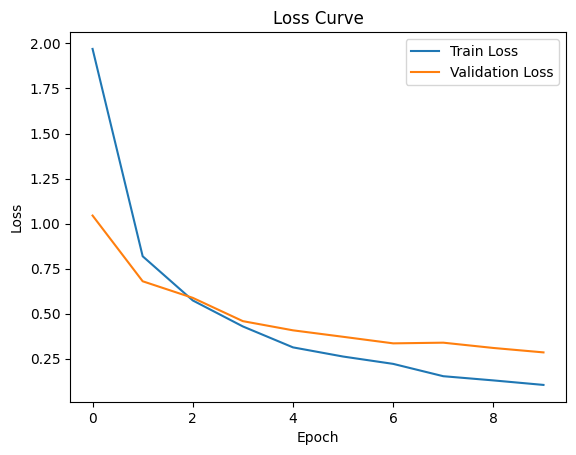

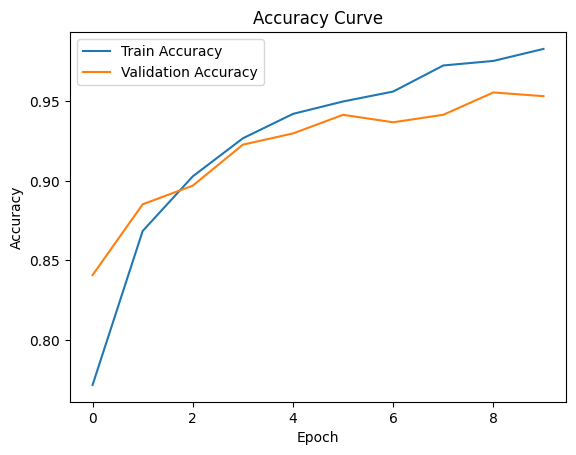

In [253]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()


In [254]:
intent_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        tokens = batch['tokens'].to(device)
        intents = batch['intent'].to(device)

        logits = intent_model(tokens)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(intents.cpu().tolist())

print("Test Intent Accuracy:", accuracy_score(all_labels, all_preds))


Test Intent Accuracy: 0.9539249146757679


In [255]:
idx2slot = {idx: label for label, idx in slot_vocab.items()}

true_slots, pred_slots = [], []

slot_model.eval()

with torch.no_grad():
    for batch in test_loader:
        tokens = batch['tokens'].to(device)
        slots = batch['slots'].to(device)

        logits = slot_model(tokens)
        preds = torch.argmax(logits, dim=-1)

        for i in range(tokens.size(0)):
            true_seq, pred_seq = [], []
            for j in range(tokens.size(1)):
                if slots[i, j].item() != SLOT_PAD_IDX:
                    true_seq.append(idx2slot[slots[i, j].item()])
                    pred_seq.append(idx2slot[preds[i, j].item()])
            true_slots.append(true_seq)
            pred_slots.append(pred_seq)

print("Slot F1 Score:", f1_score(true_slots, pred_slots))
print("\nSlot Classification Report:")
print(classification_report(true_slots, pred_slots))

Slot F1 Score: 0.9434440781131118

Slot Classification Report:
                            precision    recall  f1-score   support

             aircraft_code       1.00      0.29      0.44         7
              airline_code       1.00      0.91      0.95        22
              airline_name       0.96      0.97      0.96        91
              airport_code       0.33      0.25      0.29         4
              airport_name       0.56      0.62      0.59         8
 arrive_date.date_relative       0.00      0.00      0.00         1
      arrive_date.day_name       0.78      0.70      0.74        10
    arrive_date.day_number       1.00      1.00      1.00         7
    arrive_date.month_name       1.00      1.00      1.00         7
      arrive_time.end_time       0.60      1.00      0.75         3
    arrive_time.period_mod       0.00      0.00      0.00         1
 arrive_time.period_of_day       0.60      0.38      0.46         8
    arrive_time.start_time       1.00      0.67     

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Part 1.3 : BiLSTM Joint Model

In [256]:
def collate_fn(batch):
    tokens = [item['tokens'] for item in batch]
    slots = [item['slots'] for item in batch]
    intents = torch.tensor([item['intent'] for item in batch])

    lengths = torch.tensor([len(seq) for seq in tokens], dtype=torch.long)

    tokens_padded = pad_sequence(tokens, batch_first=True, padding_value=TOKEN_PAD_IDX)
    slots_padded = pad_sequence(slots, batch_first=True, padding_value=SLOT_PAD_IDX)

    return {
        'tokens': tokens_padded,
        'slots': slots_padded,
        'intent': intents,
        'lengths': lengths
    }

In [257]:
batch_size = 32

train_dataset = ATISDataset(train_df, token_vocab, slot_vocab, intent_vocab)
val_dataset   = ATISDataset(val_df, token_vocab, slot_vocab, intent_vocab)
test_dataset  = ATISDataset(test_df, token_vocab, slot_vocab, intent_vocab)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

## Part 1.3.1

In [ ]:
class JointBiLSTM(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_intents,
        num_slots,
        pad_idx,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            bidirectional=True,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.intent_fc = nn.Linear(hidden_dim * 2, num_intents)
        self.slot_fc = nn.Linear(hidden_dim * 2, num_slots)

    def forward(self, x, lengths):
        embedded = self.embedding(x)              
        lstm_out, _ = self.lstm(embedded)             

        lstm_out = self.dropout(lstm_out)

        idx = (lengths - 1).unsqueeze(1).unsqueeze(2)
        idx = idx.expand(-1, 1, lstm_out.size(2))
        intent_repr = lstm_out.gather(1, idx).squeeze(1)  

        intent_logits = self.intent_fc(intent_repr)      
        slot_logits = self.slot_fc(lstm_out)              

        return intent_logits, slot_logits


In [259]:
model = JointBiLSTM(
    vocab_size=len(token_vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_intents=len(intent_vocab),
    num_slots=len(slot_vocab),
    pad_idx=TOKEN_PAD_IDX,
    dropout=DROPOUT
).to(device)


In [260]:
intent_criterion = nn.CrossEntropyLoss()
slot_criterion = nn.CrossEntropyLoss(ignore_index=SLOT_PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [261]:
def compute_joint_loss(intent_logits, slot_logits, intents, slots):
    intent_loss = intent_criterion(intent_logits, intents)
    slot_loss = slot_criterion(
        slot_logits.view(-1, slot_logits.size(-1)),
        slots.view(-1)
    )
    return intent_loss + slot_loss

In [262]:
def train_one_epoch_joint(model, dataloader):
    model.train()

    total_loss = 0
    correct_intents = 0
    total_intents = 0

    for batch in dataloader:
        tokens = batch['tokens'].to(device)
        intents = batch['intent'].to(device)
        slots = batch['slots'].to(device)
        lengths = batch['lengths'].to(device)

        optimizer.zero_grad()

        intent_logits, slot_logits = model(tokens, lengths)

        loss = compute_joint_loss(
            intent_logits, slot_logits, intents, slots
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(intent_logits, dim=1)
        correct_intents += (preds == intents).sum().item()
        total_intents += intents.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct_intents / total_intents

    return avg_loss, accuracy

In [263]:
def evaluate_joint(model, dataloader):
    model.eval()

    total_loss = 0
    correct_intents = 0
    total_intents = 0

    with torch.no_grad():
        for batch in dataloader:
            tokens = batch['tokens'].to(device)
            intents = batch['intent'].to(device)
            slots = batch['slots'].to(device)
            lengths = batch['lengths'].to(device)

            intent_logits, slot_logits = model(tokens, lengths)

            loss = compute_joint_loss(
                intent_logits, slot_logits, intents, slots
            )

            total_loss += loss.item()

            preds = torch.argmax(intent_logits, dim=1)
            correct_intents += (preds == intents).sum().item()
            total_intents += intents.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct_intents / total_intents

    return avg_loss, accuracy


In [264]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch_joint(model, train_loader)
    val_loss, val_acc = evaluate_joint(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )


Epoch 1/10 | Train Loss: 2.6308, Train Acc: 0.7471 | Val Loss: 1.4159, Val Acc: 0.7963
Epoch 2/10 | Train Loss: 1.1026, Train Acc: 0.8511 | Val Loss: 0.8076, Val Acc: 0.8782
Epoch 3/10 | Train Loss: 0.6676, Train Acc: 0.9064 | Val Loss: 0.5944, Val Acc: 0.9133
Epoch 4/10 | Train Loss: 0.4678, Train Acc: 0.9374 | Val Loss: 0.4751, Val Acc: 0.9274
Epoch 5/10 | Train Loss: 0.3348, Train Acc: 0.9563 | Val Loss: 0.4212, Val Acc: 0.9344
Epoch 6/10 | Train Loss: 0.2448, Train Acc: 0.9722 | Val Loss: 0.3390, Val Acc: 0.9438
Epoch 7/10 | Train Loss: 0.1913, Train Acc: 0.9797 | Val Loss: 0.3407, Val Acc: 0.9415
Epoch 8/10 | Train Loss: 0.1489, Train Acc: 0.9862 | Val Loss: 0.3244, Val Acc: 0.9461
Epoch 9/10 | Train Loss: 0.1191, Train Acc: 0.9893 | Val Loss: 0.3049, Val Acc: 0.9438
Epoch 10/10 | Train Loss: 0.1037, Train Acc: 0.9930 | Val Loss: 0.2831, Val Acc: 0.9532


## Part 1.3.2

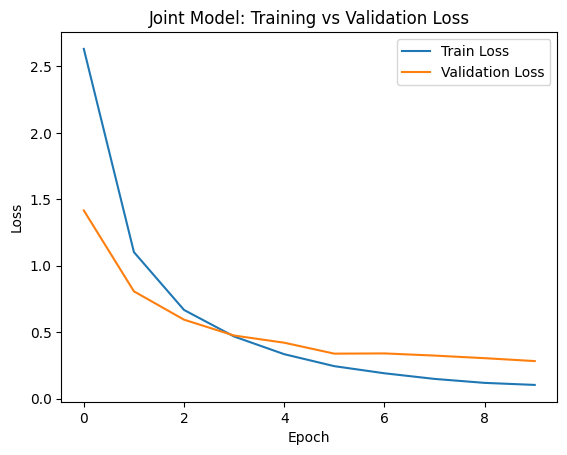

In [265]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Joint Model: Training vs Validation Loss")
plt.show()


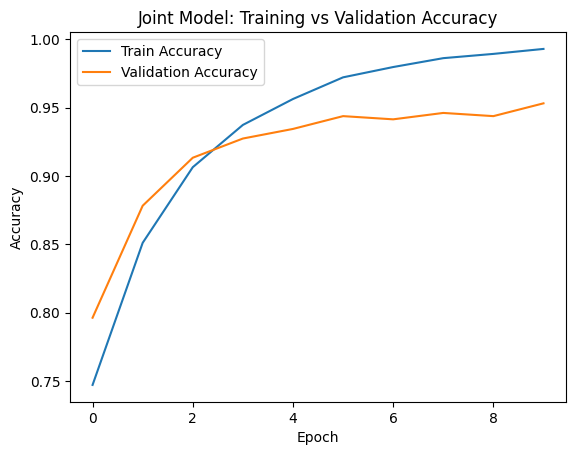

In [266]:
plt.figure()
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Joint Model: Training vs Validation Accuracy")
plt.show()


In [267]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        tokens = batch['tokens'].to(device)
        intents = batch['intent'].to(device)
        lengths = batch['lengths'].to(device)

        intent_logits, _ = model(tokens, lengths)
        preds = torch.argmax(intent_logits, dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(intents.cpu().tolist())

test_intent_accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Intent Accuracy: {test_intent_accuracy:.4f}")


Test Intent Accuracy: 0.9744


In [268]:
idx2slot = {idx: label for label, idx in slot_vocab.items()}

true_slots = []
pred_slots = []

model.eval()

with torch.no_grad():
    for batch in test_loader:
        tokens = batch['tokens'].to(device)
        slots = batch['slots'].to(device)
        lengths = batch['lengths'].to(device)

        _, slot_logits = model(tokens, lengths)
        slot_preds = torch.argmax(slot_logits, dim=-1)

        for i in range(tokens.size(0)):
            true_seq = []
            pred_seq = []

            for j in range(lengths[i]):
                true_seq.append(idx2slot[slots[i, j].item()])
                pred_seq.append(idx2slot[slot_preds[i, j].item()])

            true_slots.append(true_seq)
            pred_slots.append(pred_seq)

In [269]:
print("Slot Filling F1 Score:")
print(f1_score(true_slots, pred_slots))

print("\nSlot Classification Report:")
print(classification_report(true_slots, pred_slots))

Slot Filling F1 Score:
0.9323193916349809

Slot Classification Report:
                            precision    recall  f1-score   support

             aircraft_code       0.75      0.86      0.80         7
              airline_code       0.92      1.00      0.96        22
              airline_name       0.97      0.98      0.97        91
              airport_code       0.33      0.25      0.29         4
              airport_name       0.57      0.50      0.53         8
 arrive_date.date_relative       0.50      1.00      0.67         1
      arrive_date.day_name       1.00      0.50      0.67        10
    arrive_date.day_number       1.00      0.29      0.44         7
    arrive_date.month_name       1.00      0.57      0.73         7
      arrive_time.end_time       0.00      0.00      0.00         3
    arrive_time.period_mod       0.00      0.00      0.00         1
 arrive_time.period_of_day       0.71      0.62      0.67         8
    arrive_time.start_time       1.00      0

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Part 1.4 : Encoder–Decoder non-aligned joint Model

## Part 1.4.1 & 1.4.2

In [ ]:
SPECIAL_SLOTS = ["<BOS>", "<EOS>"]

slot_offset = len(slot_vocab)
for tok in SPECIAL_SLOTS:
    slot_vocab[tok] = slot_offset
    slot_offset += 1

SLOT_BOS_IDX = slot_vocab["<BOS>"]
SLOT_EOS_IDX = slot_vocab["<EOS>"]
SLOT_PAD_IDX = slot_vocab["<PAD>"]
SLOT_UNK_IDX = slot_vocab["<UNK>"]


In [ ]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)                  
        outputs, (hidden, cell) = self.lstm(embedded)
        return hidden, cell

class Decoder(nn.Module):
    def __init__(self, slot_vocab_size, embed_dim, hidden_dim, num_intents,
                 dropout, pad_idx, enc_hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(slot_vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)

        self.hidden_proj = nn.Linear(enc_hidden_dim, hidden_dim)
        self.cell_proj = nn.Linear(enc_hidden_dim, hidden_dim)

        self.slot_fc = nn.Linear(hidden_dim, slot_vocab_size)
        self.intent_fc = nn.Linear(hidden_dim, num_intents)

    def forward(self, x, hidden, cell):
        hidden = self.hidden_proj(hidden)
        cell = self.cell_proj(cell)

        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        outputs = self.dropout(outputs)

        slot_logits = self.slot_fc(outputs)
        intent_logits = self.intent_fc(hidden[-1])

        return slot_logits, intent_logits

class Seq2SeqJointModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg):
        hidden, cell = self.encoder(src)
        slot_logits, intent_logits = self.decoder(trg, hidden, cell)
        return slot_logits, intent_logits


In [272]:
def train_step(model, batch, optimizer):
    src = batch['tokens'].to(device)
    trg_input = batch['slot_input'].to(device)
    trg_target = batch['slot_target'].to(device)
    intents = batch['intent'].to(device)

    optimizer.zero_grad()
    slot_logits, intent_logits = model(src, trg_input)
    loss = joint_loss(slot_logits, intent_logits, trg_target, intents)
    loss.backward()
    optimizer.step()
    return loss.item()


## Part 1.4.3

In [ ]:
ENC_EMBED_DIM = 128
ENC_HIDDEN_DIM = 128

DEC_EMBED_DIM = 64
DEC_HIDDEN_DIM = 256



In [ ]:
def collate_fn(batch):
    src_tokens = []
    slot_inputs = []
    slot_targets = []
    intents = []

    for item in batch:
        src_tokens.append(torch.tensor(item['tokens'], dtype=torch.long))
        slots = torch.tensor(item['slots'], dtype=torch.long)
        slot_input = torch.cat([
            torch.tensor([SLOT_BOS_IDX]),
            slots
        ])
        slot_target = torch.cat([
            slots,
            torch.tensor([SLOT_EOS_IDX])
        ])

        slot_inputs.append(slot_input)
        slot_targets.append(slot_target)
        intents.append(item['intent'])

    src_tokens = pad_sequence(
        src_tokens, batch_first=True, padding_value=TOKEN_PAD_IDX
    )
    slot_inputs = pad_sequence(
        slot_inputs, batch_first=True, padding_value=SLOT_PAD_IDX
    )
    slot_targets = pad_sequence(
        slot_targets, batch_first=True, padding_value=SLOT_PAD_IDX
    )

    return {
        'tokens': src_tokens,
        'slot_input': slot_inputs,
        'slot_target': slot_targets,
        'intent': torch.tensor(intents, dtype=torch.long)
    }


In [275]:
batch_size = 32

train_dataset = ATISDataset(train_df, token_vocab, slot_vocab, intent_vocab)
val_dataset   = ATISDataset(val_df, token_vocab, slot_vocab, intent_vocab)
test_dataset  = ATISDataset(test_df, token_vocab, slot_vocab, intent_vocab)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [ ]:
encoder = Encoder(
    vocab_size=len(token_vocab),
    embed_dim=ENC_EMBED_DIM,
    hidden_dim=ENC_HIDDEN_DIM,
    pad_idx=TOKEN_PAD_IDX
)

decoder = Decoder(
    slot_vocab_size=len(slot_vocab),
    embed_dim=DEC_EMBED_DIM,
    hidden_dim=DEC_HIDDEN_DIM,       
    num_intents=len(intent_vocab),
    dropout=DROPOUT,
    pad_idx=SLOT_PAD_IDX,
    enc_hidden_dim=ENC_HIDDEN_DIM     
)

model = Seq2SeqJointModel(encoder, decoder).to(device)


In [277]:
intent_criterion = nn.CrossEntropyLoss()
slot_criterion = nn.CrossEntropyLoss(ignore_index=SLOT_PAD_IDX)

def joint_loss(slot_logits, intent_logits, slot_targets, intent_targets):
    slot_loss = slot_criterion(
        slot_logits.view(-1, slot_logits.size(-1)),
        slot_targets.view(-1)
    )
    intent_loss = intent_criterion(intent_logits, intent_targets)
    return slot_loss + intent_loss
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


In [278]:
def train_one_epoch(model, dataloader, optimizer):
    model.train()
    total_loss = 0
    correct_intent = 0
    total_samples = 0

    for batch in dataloader:
        src = batch['tokens'].to(device)
        trg_input = batch['slot_input'].to(device)
        trg_target = batch['slot_target'].to(device)
        intents = batch['intent'].to(device)

        optimizer.zero_grad()
        slot_logits, intent_logits = model(src, trg_input)
        loss = joint_loss(slot_logits, intent_logits, trg_target, intents)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * src.size(0)
        pred_intents = intent_logits.argmax(dim=1)
        correct_intent += (pred_intents == intents).sum().item()
        total_samples += src.size(0)

    avg_loss = total_loss / total_samples
    acc = correct_intent / total_samples
    return avg_loss, acc


In [ ]:
def evaluate(model, dataloader):
    model.eval()

    total_loss = 0.0
    correct_intent = 0
    total_samples = 0

    all_slot_preds = []
    all_slot_targets = []

    inv_slot_vocab = {v: k for k, v in slot_vocab.items()}

    with torch.no_grad():
        for batch in dataloader:
            src = batch['tokens'].to(device)
            trg_input = batch['slot_input'].to(device)
            trg_target = batch['slot_target'].to(device)
            intents = batch['intent'].to(device)

            slot_logits, intent_logits = model(src, trg_input)

            loss = joint_loss(slot_logits, intent_logits, trg_target, intents)
            total_loss += loss.item() * src.size(0)

            pred_intents = intent_logits.argmax(dim=1)
            correct_intent += (pred_intents == intents).sum().item()
            total_samples += src.size(0)

            pred_slots = slot_logits.argmax(dim=2).cpu().tolist()
            true_slots = trg_target.cpu().tolist()

            for p_seq, t_seq in zip(pred_slots, true_slots):
                pred_labels = []
                true_labels = []

                for p, t in zip(p_seq, t_seq):
                    if t == SLOT_PAD_IDX or t == SLOT_EOS_IDX:
                        break

                    true_labels.append(inv_slot_vocab[t])
                    pred_labels.append(inv_slot_vocab[p])

                all_slot_targets.append(true_labels)
                all_slot_preds.append(pred_labels)

    avg_loss = total_loss / total_samples
    intent_acc = correct_intent / total_samples

    slot_f1 = f1_score(all_slot_targets, all_slot_preds)
    slot_report = classification_report(all_slot_targets, all_slot_preds)

    return avg_loss, intent_acc, slot_f1, slot_report

In [280]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(20):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc, val_f1, val_report = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{20} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")


/tmp/ipykernel_55/2905241984.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  src_tokens.append(torch.tensor(item['tokens'], dtype=torch.long))
/tmp/ipykernel_55/2905241984.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  slots = torch.tensor(item['slots'], dtype=torch.long)
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: <EOS> seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this beha

Epoch 1/20 | Train Loss: 2.9397, Train Acc: 0.7260 | Val Loss: 2.2457, Val Acc: 0.7541 | Val F1: 0.2393
Epoch 2/20 | Train Loss: 2.0747, Train Acc: 0.7541 | Val Loss: 1.8888, Val Acc: 0.7681 | Val F1: 0.3163
Epoch 3/20 | Train Loss: 1.8700, Train Acc: 0.7603 | Val Loss: 1.7344, Val Acc: 0.7799 | Val F1: 0.3667
Epoch 4/20 | Train Loss: 1.6371, Train Acc: 0.8136 | Val Loss: 1.6012, Val Acc: 0.8314 | Val F1: 0.3584
Epoch 5/20 | Train Loss: 1.4695, Train Acc: 0.8607 | Val Loss: 1.4386, Val Acc: 0.8384 | Val F1: 0.3713
Epoch 6/20 | Train Loss: 1.3278, Train Acc: 0.8799 | Val Loss: 1.3770, Val Acc: 0.8501 | Val F1: 0.3791
Epoch 7/20 | Train Loss: 1.2343, Train Acc: 0.8921 | Val Loss: 1.2982, Val Acc: 0.8478 | Val F1: 0.3945
Epoch 8/20 | Train Loss: 1.1702, Train Acc: 0.9033 | Val Loss: 1.2079, Val Acc: 0.8806 | Val F1: 0.4277
Epoch 9/20 | Train Loss: 1.0761, Train Acc: 0.9228 | Val Loss: 1.1475, Val Acc: 0.8876 | Val F1: 0.4283
Epoch 10/20 | Train Loss: 1.0119, Train Acc: 0.9251 | Val Loss: 

In [281]:
test_loss, test_acc, test_f1, test_report = evaluate(model, test_loader)

print(f"Test Intent Accuracy: {test_acc:.4f}")
print(f"Test Slot F1 Score: {test_f1:.4f}")
print("Slot Classification Report:\n", test_report)


Test Intent Accuracy: 0.9386
Test Slot F1 Score: 0.5082
Slot Classification Report:
                             precision    recall  f1-score   support

                      EOS>       0.00      0.00      0.00         0
             aircraft_code       0.00      0.00      0.00         7
              airline_code       1.00      0.05      0.09        22
              airline_name       0.03      0.02      0.02        91
              airport_code       0.00      0.00      0.00         4
              airport_name       0.00      0.00      0.00         8
 arrive_date.date_relative       0.00      0.00      0.00         1
      arrive_date.day_name       1.00      0.10      0.18        10
    arrive_date.day_number       0.86      0.86      0.86         7
    arrive_date.month_name       0.00      0.00      0.00         7
      arrive_time.end_time       1.00      1.00      1.00         3
    arrive_time.period_mod       0.00      0.00      0.00         1
 arrive_time.period_of_day    

/tmp/ipykernel_55/2905241984.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  src_tokens.append(torch.tensor(item['tokens'], dtype=torch.long))
/tmp/ipykernel_55/2905241984.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  slots = torch.tensor(item['slots'], dtype=torch.long)


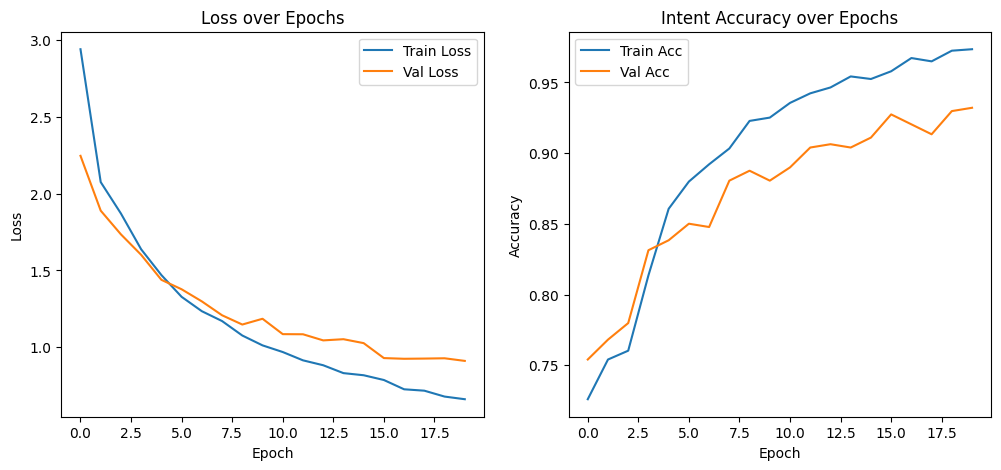

In [282]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Epochs")

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Intent Accuracy over Epochs")
plt.show()


In [ ]:
def greedy_decode(model, src, max_len=50):
    model.eval()

    with torch.no_grad():
        hidden, cell = model.encoder(src)
        decoder_input = torch.tensor([[SLOT_BOS_IDX]], device=device)

        decoded_slots = []

        for _ in range(max_len):
            slot_logits, intent_logits = model.decoder(decoder_input, hidden, cell)
            next_token = slot_logits[:, -1, :].argmax(dim=-1).item()

            if next_token == SLOT_EOS_IDX:
                break

            decoded_slots.append(next_token)
            decoder_input = torch.cat(
                [decoder_input, torch.tensor([[next_token]], device=device)],
                dim=1
            )

        intent_pred = intent_logits.argmax(dim=1).item()

    return decoded_slots, intent_pred


In [284]:
inv_token_vocab = {v: k for k, v in token_vocab.items()}
inv_slot_vocab = {v: k for k, v in slot_vocab.items()}
inv_intent_vocab = {v: k for k, v in intent_vocab.items()}

In [ ]:
model.eval()
print("=" * 80)

for i in range(5):
    item = test_dataset[i]

    src = item['tokens'].unsqueeze(0).to(device)   
    true_slots = item['slots']
    true_intent = item['intent']

    pred_slots, pred_intent = greedy_decode(model, src)

    sentence = [inv_token_vocab[t.item()] for t in item['tokens']]
    true_slot_labels = [inv_slot_vocab[s.item()] for s in true_slots]
    pred_slot_labels = [inv_slot_vocab[s] for s in pred_slots]

    print(f"Sentence {i+1}")
    print("Tokens:       ", sentence)
    print("True Slots:   ", true_slot_labels)
    print("Pred Slots:   ", pred_slot_labels)
    print("True Intent:  ", inv_intent_vocab[true_intent.item()])
    print("Pred Intent:  ", inv_intent_vocab[pred_intent])
    print("-" * 80)


Sentence 1
Tokens:        ['BOS', 'what', 'are', 'the', 'coach', 'flights', 'between', 'dallas', 'and', 'baltimore', 'leaving', 'august', 'tenth', 'and', 'returning', 'august', 'twelve', 'EOS']
True Slots:    ['O', 'O', 'O', 'O', 'B-class_type', 'O', 'O', 'B-fromloc.city_name', 'O', 'B-toloc.city_name', 'O', 'B-depart_date.month_name', 'B-depart_date.day_number', 'O', 'O', 'B-return_date.month_name', 'B-return_date.day_number', 'O']
Pred Slots:    ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-fromloc.city_name', 'O', 'B-toloc.city_name', 'O', 'O', 'O', 'O', 'O', 'O']
True Intent:   atis_flight
Pred Intent:   atis_flight
--------------------------------------------------------------------------------
Sentence 2
Tokens:        ['BOS', 'i', 'want', 'a', 'flight', 'from', 'nashville', 'to', 'seattle', 'that', 'arrives', 'no', 'later', 'than', '3', 'pm', 'EOS']
True Slots:    ['O', 'O', 'O', 'O', 'O', 'O', 'B-fromloc.city_name', 'O', 'B-toloc.city_name', 'O', 'O', 'B-arrive_time.time_relative', 'I